In this notebook, we present an analysis of the Maximum Likelihood Estimation (MLE) method. 

Focusing on the 3-qubit GHZ state ($\text{GHZ}_3$), we investigate the scaling of both the classical fidelity ($F_c$) and quantum fidelity ($F_q$) as a function of the number of measurement samples ($N_{\text{samples}}$). 

Furthermore, we explore the *curse of dimensionality* and the poor scalability of the MLE approach as the number of qubits ($N_{\text{qubits}}$) increases.

# Import

In [1]:
# general import: 
import sys
import time
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [2]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [3]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
# from vae import *
from plots import *
from utils import *
from mle import *

In [8]:
# repo directory
PROJECT_DIR = Path.cwd().parent   

# figs directory
FIGS_DIR = PROJECT_DIR / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# MLE data directory
DATA_DIR = PROJECT_DIR / 'data' / 'MLE_analysis'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# $F_q, F_c$ vs $N_{sample}$

### data sampling

In [5]:
# --- helper functions ---

# wrapper of sample_povm for a better comprension in the for-cicle
def generate_dataset(p_exact, seed_data, n_samples=500):
    samples = sample_povm(p_exact, n_samples, seed=seed_data)
    return samples

# function to run a single reconstruction and computing the metrics of interest
def mle_fidelities(samples, rho_true, p_exact, N):
    # minuit routine: 
    nll = make_nll(samples, N)

    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)

    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
    m.migrad()
    if not m.valid:
        m.migrad()                                

    # fidelity evaluation
    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc    = classical_fidelity(p_exact, p_mle)
    fq    = quantum_fidelity(rho_true, rho_mle)

    return float(fc), float(fq)

In [6]:
# state preparation: GHZ3 
N = 3
qc = create_ghz_state(N)
rho_true = DensityMatrix(qc)
p_exact = povm_probability(rho_true.data, N)

We run $B=50$ independent experiments to reconstruct the distributions of both classical and quantum fidelities. 

To study the scaling behavior, we vary the number of samples across the following values:
$$N_{\text{samples}} \in [100, 200, 500, 1000, 5000, 10000]$$

In [ ]:
B = 50           
n_samples = 10000   # run the same cell using [100, 200, 500, 1000, 5000, 10000]

rows = []
for b in range(B):
    samples = generate_dataset(p_exact=p_exact, seed_data=42 + b, n_samples=n_samples)
    fc_toy, fq_toy = mle_fidelities(samples, rho_true, p_exact, N)                                                  

    rows.append(dict(method='MLE', b=b, N=n_samples, F_c=fc_toy, F_q=fq_toy))

    if b % 1 == 0:
        print(f"{b+1}/{B}  F_c: {fc_toy:.4f} \t F_q: {fq_toy:.4f}")


# -- save results --
df = pd.DataFrame(rows)

file_name = f'MLE_results_run_N{n_samples}_B{B}_ghz.csv'

df.to_csv(DATA_DIR / file_name, index=False)

print("\n Saved!\t N_rows:", len(df))

1/50  F_c: 0.9997 	 F_q: 0.9604
2/50  F_c: 0.9998 	 F_q: 0.9694
3/50  F_c: 0.9996 	 F_q: 0.9586
4/50  F_c: 0.9996 	 F_q: 0.9548
5/50  F_c: 0.9997 	 F_q: 0.9614
6/50  F_c: 0.9994 	 F_q: 0.9421
7/50  F_c: 0.9997 	 F_q: 0.9588
8/50  F_c: 0.9998 	 F_q: 0.9624
9/50  F_c: 0.9995 	 F_q: 0.9526
10/50  F_c: 0.9998 	 F_q: 0.9666
11/50  F_c: 0.9996 	 F_q: 0.9518
12/50  F_c: 0.9997 	 F_q: 0.9581
13/50  F_c: 0.9996 	 F_q: 0.9534
14/50  F_c: 0.9995 	 F_q: 0.9433
15/50  F_c: 0.9997 	 F_q: 0.9635
16/50  F_c: 0.9996 	 F_q: 0.9533
17/50  F_c: 0.9997 	 F_q: 0.9510
18/50  F_c: 0.9997 	 F_q: 0.9773
19/50  F_c: 0.9996 	 F_q: 0.9575
20/50  F_c: 0.9997 	 F_q: 0.9648
21/50  F_c: 0.9997 	 F_q: 0.9598
22/50  F_c: 0.9997 	 F_q: 0.9551
23/50  F_c: 0.9997 	 F_q: 0.9496
24/50  F_c: 0.9996 	 F_q: 0.9684
25/50  F_c: 0.9996 	 F_q: 0.9645
26/50  F_c: 0.9997 	 F_q: 0.9747
27/50  F_c: 0.9998 	 F_q: 0.9734
28/50  F_c: 0.9998 	 F_q: 0.9641
29/50  F_c: 0.9997 	 F_q: 0.9578
30/50  F_c: 0.9996 	 F_q: 0.9557
31/50  F_c: 0.9997 

### plot

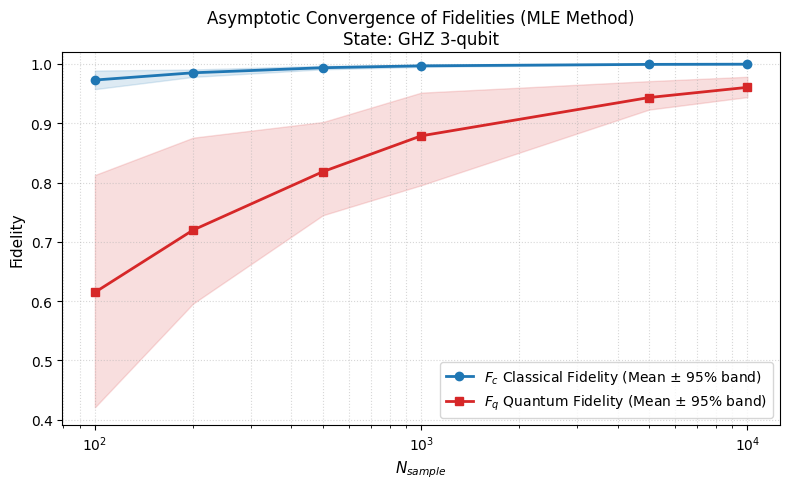

In [9]:
# --- load data ---
paths = sorted(DATA_DIR.glob("MLE_results_run_N*_B50_ghz.csv"))         # look for all csv files
df_cmp = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
df_cmp = df_cmp.rename(columns={'N': 'N_sample'})

# isolate only the MLE method (the only one containing both F_c and F_q) --> at this stage is the only one present
df_mle = df_cmp[df_cmp.method == 'MLE']

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# extract F_c and F_q statistics
g_fc = df_mle.groupby('N_sample')['F_c']
g_fq = df_mle.groupby('N_sample')['F_q']

# x-axis coordinates
n_values = sorted(df_mle.N_sample.unique())

# classical fidelity Fc
ax.fill_between(n_values, 
                g_fc.quantile(0.025).values, 
                g_fc.quantile(0.975).values, 
                color='C0', alpha=0.15)

ax.plot(n_values, g_fc.mean().values, 'o-', color='C0', linewidth=2, 
        label=r'$F_c$ Classical Fidelity (Mean $\pm$ 95% band)')

# quantum fidelity Fq
ax.fill_between(n_values, 
                g_fq.quantile(0.025).values, 
                g_fq.quantile(0.975).values, 
                color='C3', alpha=0.15)

ax.plot(n_values, g_fq.mean().values, 's-', color='C3', linewidth=2, 
        label=r'$F_q$ Quantum Fidelity (Mean $\pm$ 95% band)')

# --- plot settings ---
ax.set_xscale('log')
ax.set_ylim(None, 1.02) 
ax.set_xlabel(r"$N_{sample}$", fontsize=11)
ax.set_ylabel("Fidelity", fontsize=11)

ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(loc='lower right')

# --- title ---
ax.set_title("Asymptotic Convergence of Fidelities (MLE Method)\nState: GHZ 3-qubit")

fig.tight_layout()

# -- save fig --
fig.savefig(FIGS_DIR / 'MLE_convergence_fidelities.svg', bbox_inches='tight')

plt.show()

We compute and display the 95% confidence interval (or percentile band) of the fidelity distribution instead of the standard deviation since fidelity probabilities are bounded by a maximum value of 1 and the distribution can become skewed near this boundary.

# MLE *curse-of-dimensionality*

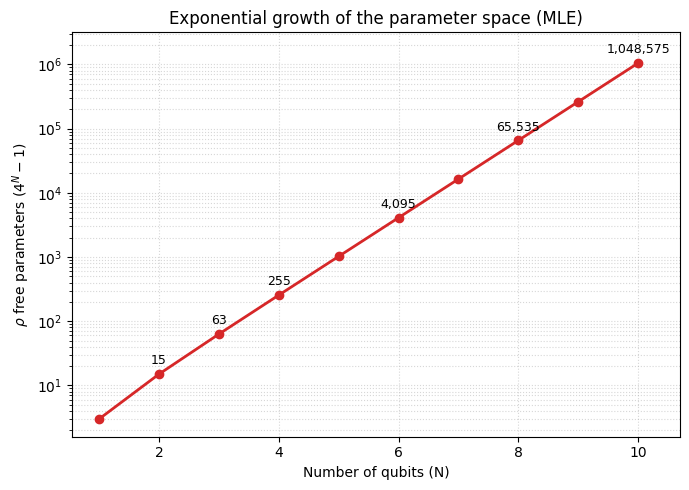

 N qubit |    dim rho |     N params
------------------------------------
       1 | 2x2      |            3
       2 | 4x4      |           15
       3 | 8x8      |           63
       4 | 16x16     |          255
       5 | 32x32     |        1,023
       6 | 64x64     |        4,095
       7 | 128x128    |       16,383
       8 | 256x256    |       65,535
       9 | 512x512    |      262,143
      10 | 1024x1024   |    1,048,575


In [10]:
# didatical plots to show the scalability of free parameters of the density matrix 
 
n_qubits = np.arange(1, 11)          
n_params = 4**n_qubits - 1           
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(n_qubits, n_params, marker='o', linewidth=2, color='#d62728')
ax.set_yscale('log')
ax.set_ylim(top=10**6.5)
ax.set_xlim(right=10.7)
ax.set_xlabel('Number of qubits (N)')
ax.set_ylabel(r'$\rho$ free parameters ($4^N - 1$)')

ax.set_title('Exponential growth of the parameter space (MLE)')

ax.grid(True, which='both', ls=':', alpha=0.5)
 
# inserting some values
for n in [2, 3, 4, 6, 8, 10]:
    ax.annotate(f'{4**n - 1:,}', xy=(n, 4**n - 1),
                xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=9)
 
fig.tight_layout()

# -- save fig --
fig.savefig(FIGS_DIR / 'MLE_exp_growth_params.svg', bbox_inches='tight')

plt.show()
 
# summary
print(f"{'N qubit':>8} | {'dim rho':>10} | {'N params':>12}")
print("-" * 36)
for n in n_qubits:
    print(f"{n:>8} | {2**n}x{2**n:<6} | {4**n - 1:>12,}")


NB: This is a very naive plot showing the exponential growth in the number of free parameters. However, while a Neural Network (NN) could be characterized by a similar number of weights, its training algorithms are highly parallelizable, significantly reducing the actual computation time.

### MLE time-of-minimization vs $N_{qubit}$

The idea is to give a rough but concrete descripion of the course-of-dimensionality problem by measuring the time of minimization vs dim (N_qubits)

In [ ]:
# helper to measure the time of processing
def fit_mle_timed(p_exact, samples, N):

    nll = make_nll(samples, N)
 
    dim = 2**N
    init_rho = np.eye(dim, dtype=complex) / dim
    p0 = rho_to_params(init_rho, N)
 
    m = Minuit(nll, *p0)
    m.errordef = Minuit.LIKELIHOOD
    m.print_level = 0
 
    t0 = time.perf_counter()
    m.migrad()
    if not m.valid:
        m.migrad()
    elapsed = time.perf_counter() - t0
 
    rho_mle = params_to_rho(np.array(m.values), N)
    p_mle = povm_probability(rho_mle, N)
    fc = classical_fidelity(p_exact, p_mle)
 
    return float(fc), elapsed, m.valid

In [ ]:
# rough measure of the time of minimization vs dim (N_qubits)
# the idea is to give a rough but concrete descripion of the course-of-dimensionality problem

qubit_range = [2, 3, 4]     # tested space dim - N of qubits      
N_SAMPLE = 500              # reasonable n of samples fixed              
 
results_time = []
 
for N in qubit_range:
    print(f"--- N = {N} qubit ---")
 
    qc = create_ghz_state(N)                          
    rho_true = DensityMatrix(qc)
    p_exact = povm_probability(rho_true.data, N)
    samples = generate_dataset(p_exact, seed_data=42, n_samples=N_SAMPLE)   
 
    fc, elapsed, valid = fit_mle_timed(p_exact, samples, N)
 
    print(f"  F_c = {fc:.4f}   tempo = {elapsed:.2f}s   convergenza valida = {valid}")
    results_time.append({'N_qubit': N, 'F_c': fc, 'time_s': elapsed, 'valid': valid})
 
import pandas as pd
df_time = pd.DataFrame(results_time)
print(df_time)

--- N = 2 qubit ---
  F_c = 0.9978   tempo = 0.38s   convergenza valida = True
--- N = 3 qubit ---
  F_c = 0.9924   tempo = 10.44s   convergenza valida = True
--- N = 4 qubit ---
  F_c = 0.9821   tempo = 311.32s   convergenza valida = True
   N_qubit       F_c      time_s  valid
0        2  0.997780    0.377046   True
1        3  0.992438   10.444609   True
2        4  0.982129  311.322883   True


In [ ]:
# save df
df_time.to_csv(DATA_DIR / 'MLE_time.csv', index=False)
print("Saved! \t N_rows :", len(df_time))

Saved! 	 N_rows : 3


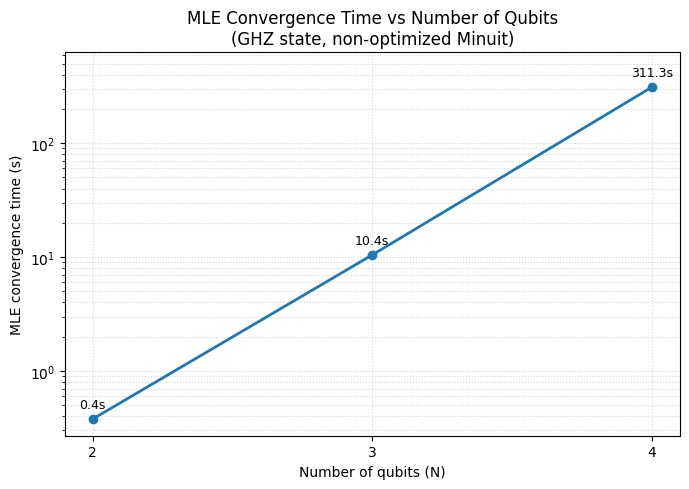

In [12]:
# --- load ---
df_time = pd.read_csv(DATA_DIR / 'MLE_time.csv')

# --- plot ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df_time['N_qubit'], df_time['time_s'], marker='o', linewidth=2, color='#1f77b4')

ax.set_yscale('log')
ax.set_xlabel('Number of qubits (N)')
ax.set_ylabel('MLE convergence time (s)')
ax.set_ylim(top=10**2.8)
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.set_xticks(df_time['N_qubit'])

# - title -
ax.set_title('MLE Convergence Time vs Number of Qubits\n(GHZ state, non-optimized Minuit)')

for _, row in df_time.iterrows():
    ax.annotate(f"{row['time_s']:.1f}s", xy=(row['N_qubit'], row['time_s']),
                xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)
 
fig.tight_layout()

# -- save fig --
fig.savefig(FIGS_DIR / 'MLE_expo_growth_time.svg', bbox_inches='tight')

plt.show()

NB: This measurement is indicative rather than absolute, Minuit has not been optimized. The trend (rapid growth with N) is the robust result, not the specific value in seconds.

NB: The true bottleneck of this method lies in the reconstruction of the entire density matrix and the computation of the outcome probabilities within the Negative Log-Likelihood (NLL) function. This process requires explicitly storing and manipulating $4^N$ POVM operators (one for each possible measurement outcome) leading to an exponential memory usage that becomes intractable as $N$ increases.

$\rightarrow$ We face the exact same bottleneck during the synthetic data simulation phase of our framework. Because we generate the training samples by sampling directly from the exact, full-dimensional density matrix ($\rho$) using the Born Rule, this simulation scales exponentially, representing the primary constraint on our VAE's scalability analysis to a higher number of qubits.